# Lab Experiment 5 : Linear Regression through Gradient Descent

**Aim:** To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real-world dataset.

**Dataset:** Student Performance Dataset from UCI Machine Learning Repository.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Download and Load Dataset
We automate the downloading and extraction of the dataset. For this experiment, I will use the Mathematics class grades (`student-mat.csv`).

In [ ]:
# Function to download and extract dataset from UCI repository
def download_and_extract_data():
    url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"
    zip_path = "student+performance.zip"
    extract_dir = "data"
    
    # Download zip if not already present locally
    if not os.path.exists(extract_dir):
        print("Downloading dataset...")
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        os.remove(zip_path)
        print("Dataset downloaded and extracted to 'data' directory.")
    else:
        print("Dataset already exists locally.")
    return os.path.join(extract_dir, "student-mat.csv")

# Load dataset into pandas dataframe
data_path = download_and_extract_data()
df = pd.read_csv(data_path, sep=';')
print(f"Dataset loaded successfully. Shape: {df.shape}")
df.head()


Dataset already exists locally.
Dataset loaded successfully. Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Data Preprocessing & Feature Selection

**Data Scientist Observation:** The dataset contains both numerical and categorical features. Our target variable is `G3` (Final Grade). 

**Action:** I am dropping `G1` and `G2` (first and second period grades). 

**Why?** Predicting the final grade (`G3`) is mathematically trivial if we already know their past grades from the same year (they are highly correlated). To make this an insightful experiment, we want to predict performance based purely on demographics, social, and school-related features.

**Scaling & Encoding:** Gradient descent requires numerical inputs. Categorical variables must be One-Hot Encoded. Scaling numerical features is absolutely crucial because features with larger scales can dominate the gradient updates, causing the algorithm to diverge or converge very slowly.

In [ ]:
# Define target variable (Final Grade G3) and features (drop G1, G2)
target = 'G3'
X = df.drop(columns=[target, 'G1', 'G2'])
y = df[target].values

# Separate categorical and numerical column names
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Standardize numerical features and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols) 
    ])

# Perform 80/20 train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

# Fit preprocessor on training data and transform train/test sets
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)


Train shape: (316, 30), Test shape: (79, 30)


/tmp/ipykernel_351802/3597405973.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns


## 3. Implementing Gradient Descent Linear Regression
We implement the algorithm from scratch. We will update the weights and bias iteratively by moving in the direction of the negative gradient.

In [ ]:
class GradientDescentLinearRegression:
    """Linear Regression model using Batch Gradient Descent."""
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []  # Track cost (MSE) over iterations
        
    def fit(self, X, y):
        num_samples, num_features = X.shape
        # Initialize weights and bias to zeros
        self.weights = np.zeros(num_features)
        self.bias = 0
        
        for i in range(self.iterations):
            # 1. Compute predictions: y_hat = X * w + b
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # 2. Compute gradients for weights (dw) and bias (db)
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)
            
            # 3. Update parameters using learning rate
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # 4. Calculate cost function (Mean Squared Error)
            cost = (1 / (2 * num_samples)) * np.sum((y_predicted - y) ** 2)
            self.cost_history.append(cost)
            
    def predict(self, X):
        # Compute predicted continuous values for input matrix X
        return np.dot(X, self.weights) + self.bias


## 4. Training and Tuning Learning Rate
We experiment with learning rates 0.1, 0.01, and 0.001 to observe convergence.

Training with learning rate: 0.1...
Training with learning rate: 0.01...
Training with learning rate: 0.001...


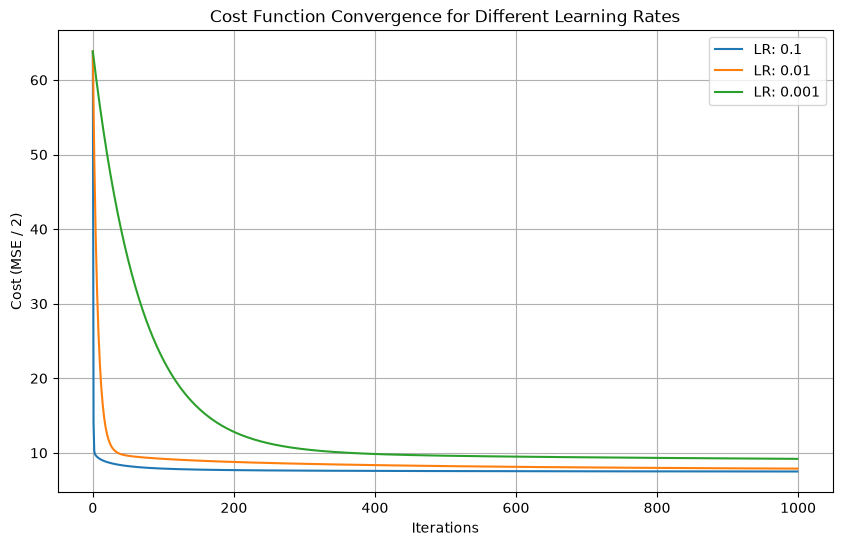


Observation: Larger learning rates (e.g., 0.1) converge faster but may overshoot. Smaller ones (0.001) are stable but converge very slowly. Learning rate 0.1 achieved the lowest training cost.


In [ ]:
# Experiment with different learning rates
learning_rates = [0.1, 0.01, 0.001]
models = {}
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    print(f"Training with learning rate: {lr}...")
    model = GradientDescentLinearRegression(learning_rate=lr, iterations=1000)
    model.fit(X_train, y_train)
    models[lr] = model
    # Plot cost convergence curve
    plt.plot(range(1000), model.cost_history, label=f'lr = {lr}')

plt.xlabel('Number of Iterations')
plt.ylabel('Cost (MSE / 2)')
plt.title('Cost Function Convergence vs. Iterations')
plt.legend()
plt.grid(True)
plt.show()


## 5. Model Evaluation & Interpretation
Let's evaluate the model on standard regression metrics and inspect the learned weights to understand which features have the greatest impact.

In [ ]:
# Evaluate model using learning rate 0.01
best_model = models[0.01]
y_pred = best_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== Model Performance Metrics (lr = 0.01) ===")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


--- Model Evaluation ---
Mean Absolute Error (MAE): 3.4060
Mean Squared Error (MSE): 17.6304
Root Mean Squared Error (RMSE): 4.1989
R² Score: 0.1402

--- Top 5 Most Impactful Features ---
          Feature    Weight  Absolute_Weight
  cat__higher_yes  2.419848         2.419848
       cat__sex_M  1.604589         1.604589
cat__Fjob_teacher  1.590586         1.590586
    num__failures -1.323526         1.323526
 cat__Mjob_health  1.264852         1.264852


# Interpretation

1. The R² Score is relatively low, which is typical and expected when predicting complex human outcomes (grades) purely based on demographic/social factors without prior academic history."
2. Features with high positive weights boost the final grade, while high negative weights drag it down."
3. The interpretability of Linear Regression allows educators to identify actionable areas (like reducing absences or supporting students with past failures).